In [4]:
import pandas as pd
import numpy as np

# LOAD DATA (HANDLE YF MULTI-HEADER)

df = pd.read_csv(
    "data/raw/nifty50.csv",
    skiprows=2   # skip 'Price' and 'Ticker' rows
)

# Rename columns properly
df.columns = ["Date", "Adj_Close", "Close", "High", "Low", "Open", "Volume"]

# Convert Date
df["Date"] = pd.to_datetime(df["Date"])

# Sort by Date
df = df.sort_values("Date").reset_index(drop=True)


# COMPUTE LOG RETURNS

df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

# Drop first NaN
df = df.dropna().reset_index(drop=True)

# SANITY CHECK

print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nRows:", len(df))
print("\nReturn stats:")
print(df["log_return"].describe())


        Date    Adj_Close        Close         High          Low         Open  \
0 2014-01-03  6211.149902  6211.149902  6221.700195  6171.250000  6194.549805   
1 2014-01-06  6191.450195  6191.450195  6224.700195  6170.250000  6220.850098   
2 2014-01-07  6162.250000  6162.250000  6221.500000  6144.750000  6203.899902   
3 2014-01-08  6174.600098  6174.600098  6192.100098  6160.350098  6178.049805   
4 2014-01-09  6168.350098  6168.350098  6188.049805  6148.250000  6181.700195   

   Volume  log_return  
0  139000   -0.001609  
1  118300   -0.003177  
2  138600   -0.004727  
3  146900    0.002002  
4  150100   -0.001013  

Columns: ['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'log_return']

Rows: 2972

Return stats:
count    2972.000000
mean        0.000477
std         0.010115
min        -0.139038
25%        -0.004175
50%         0.000672
75%         0.005842
max         0.084003
Name: log_return, dtype: float64


In [5]:
# FUTURE REALIZED VOLATILITY

HORIZONS = [5, 10]

for h in HORIZONS:
    df[f"vol_{h}d"] = (
        df["log_return"]
        .rolling(window=h)
        .std()
        .shift(-h)
    )

# Drop rows where future volatility is NaN
df = df.dropna().reset_index(drop=True)

# SANITY CHECK

print(df[["Date", "log_return", "vol_5d", "vol_10d"]].head())
print("\nVolatility stats:")
print(df[["vol_5d", "vol_10d"]].describe())


        Date  log_return    vol_5d   vol_10d
0 2014-01-03   -0.001609  0.002716  0.007902
1 2014-01-06   -0.003177  0.008042  0.007967
2 2014-01-07   -0.004727  0.008090  0.007636
3 2014-01-08    0.002002  0.009212  0.007649
4 2014-01-09   -0.001013  0.009109  0.007568

Volatility stats:
            vol_5d      vol_10d
count  2962.000000  2962.000000
mean      0.008121     0.008554
std       0.006023     0.005370
min       0.000982     0.001979
25%       0.004841     0.005649
50%       0.006864     0.007440
75%       0.009596     0.009746
max       0.084157     0.068084


In [10]:
df.describe

<bound method NDFrame.describe of            Date     Adj_Close         Close          High           Low  \
0    2014-01-03   6211.149902   6211.149902   6221.700195   6171.250000   
1    2014-01-06   6191.450195   6191.450195   6224.700195   6170.250000   
2    2014-01-07   6162.250000   6162.250000   6221.500000   6144.750000   
3    2014-01-08   6174.600098   6174.600098   6192.100098   6160.350098   
4    2014-01-09   6168.350098   6168.350098   6188.049805   6148.250000   
...         ...           ...           ...           ...           ...   
2957 2026-01-16  25694.349609  25694.349609  25873.500000  25662.400391   
2958 2026-01-19  25585.500000  25585.500000  25653.300781  25494.349609   
2959 2026-01-20  25232.500000  25232.500000  25585.000000  25171.349609   
2960 2026-01-21  25157.500000  25157.500000  25300.949219  24919.800781   
2961 2026-01-22  25289.900391  25289.900391  25435.750000  25168.500000   

              Open  Volume  log_return    vol_5d   vol_10d  
0   

In [11]:
# LAGGED RETURN FEATURES

df["ret_lag_1"] = df["log_return"].shift(1)
df["ret_lag_5"] = df["log_return"].shift(5)
df["ret_lag_10"] = df["log_return"].shift(10)

# ROLLING VOLATILITY (PAST)

df["roll_vol_5"] = df["log_return"].rolling(window=5).std()
df["roll_vol_10"] = df["log_return"].rolling(window=10).std()
df["roll_vol_20"] = df["log_return"].rolling(window=20).std()

# ROLLING MEAN RETURNS

df["roll_mean_5"] = df["log_return"].rolling(window=5).mean()
df["roll_mean_10"] = df["log_return"].rolling(window=10).mean()

# VOLUME FEATURES

df["log_volume"] = np.log(df["Volume"])
df["roll_vol_volume_10"] = df["log_volume"].rolling(window=10).std()

# DROP NaNs CREATED BY ROLLING

df = df.dropna().reset_index(drop=True)

# SANITY CHECK

print(df.head())
print("\nTotal rows after feature engineering:", len(df))


        Date    Adj_Close        Close         High          Low         Open  \
0 2014-01-30  6073.700195  6073.700195  6082.850098  6027.250000  6067.000000   
1 2014-01-31  6089.500000  6089.500000  6097.850098  6067.350098  6082.750000   
2 2014-02-03  6001.799805  6001.799805  6074.850098  5994.450195  6058.799805   
3 2014-02-04  6000.899902  6000.899902  6017.799805  5933.299805  5947.600098   
4 2014-02-05  6022.399902  6022.399902  6028.049805  5962.049805  6004.250000   

   Volume  log_return    vol_5d   vol_10d  ret_lag_1  ret_lag_5  ret_lag_10  \
0  208100   -0.007635  0.007545  0.007040  -0.000980   0.001056   -0.000316   
1  146700    0.002598  0.007820  0.007533  -0.007635  -0.012512   -0.009101   
2  134900   -0.014507  0.002540  0.006908   0.002598  -0.021109    0.006733   
3  183300   -0.000150  0.002335  0.006889  -0.014507  -0.001566    0.001561   
4  166600    0.003576  0.002324  0.007917  -0.000150  -0.000980    0.003975   

   roll_vol_5  roll_vol_10  roll_vol_2

C:\Users\Om Timbadiya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [13]:
# DEFINE FEATURES & TARGET

FEATURE_COLS = [
    "ret_lag_1", "ret_lag_5", "ret_lag_10",
    "roll_vol_5", "roll_vol_10", "roll_vol_20",
    "roll_mean_5", "roll_mean_10",
    "log_volume", "roll_vol_volume_10"
]

TARGET_COL = "vol_5d"   # we start with 5-day volatility

X = df[FEATURE_COLS]
y = df[TARGET_COL]

# TIME-BASED SPLIT

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

# SANITY CHECK

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain date range:", df.iloc[:train_end]["Date"].min(), "→", df.iloc[:train_end]["Date"].max())
print("Test date range :", df.iloc[val_end:]["Date"].min(), "→", df.iloc[val_end:]["Date"].max())


Train: (1895, 10)
Validation: (406, 10)
Test: (407, 10)

Train date range: 2014-01-30 00:00:00 → 2022-07-07 00:00:00
Test date range : 2024-05-17 00:00:00 → 2026-01-22 00:00:00


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# BASELINE 1: NAIVE ROLLING VOL
# -----------------------------
y_pred_naive = X_test["roll_vol_5"]

# -----------------------------
# BASELINE 2: EWMA VOLATILITY
# -----------------------------
def ewma_vol(series, alpha=0.94):
    ewma = []
    var = series.iloc[0] ** 2
    for r in series:
        var = alpha * var + (1 - alpha) * (r ** 2)
        ewma.append(np.sqrt(var))
    return np.array(ewma)

# Compute EWMA on full series, then align with test set
ewma_full = ewma_vol(df["log_return"])
df["ewma_vol"] = ewma_full

y_pred_ewma = df.iloc[val_end:]["ewma_vol"]

# -----------------------------
# EVALUATION
# -----------------------------
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    print(f"{name} → MAE: {mae:.6f}, RMSE: {rmse:.6f}")

print("Baseline performance on TEST set:\n")

evaluate(y_test, y_pred_naive, "Naive Rolling Vol")
evaluate(y_test, y_pred_ewma, "EWMA Vol")


Baseline performance on TEST set:

Naive Rolling Vol → MAE: 0.003618, RMSE: 0.006350
EWMA Vol → MAE: 0.003349, RMSE: 0.005420


C:\Users\Om Timbadiya\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Om Timbadiya\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [15]:
from xgboost import XGBRegressor

# -----------------------------
# MODEL CONFIG
# -----------------------------
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# -----------------------------
# TRAIN WITH VALIDATION
# -----------------------------
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# -----------------------------
# TEST SET PREDICTION
# -----------------------------
y_pred_xgb = xgb_model.predict(X_test)

# -----------------------------
# EVALUATION
# -----------------------------
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = mean_squared_error(y_test, y_pred_xgb, squared=False)

print("XGBoost Performance on TEST set:")
print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")


XGBoost Performance on TEST set:
MAE : 0.003195
RMSE: 0.005156


C:\Users\Om Timbadiya\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


              feature  importance
7        roll_mean_10    0.372212
5         roll_vol_20    0.164458
4         roll_vol_10    0.149827
8          log_volume    0.077716
6         roll_mean_5    0.057925
9  roll_vol_volume_10    0.051857
3          roll_vol_5    0.035346
1           ret_lag_5    0.034633
2          ret_lag_10    0.028397
0           ret_lag_1    0.027628


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

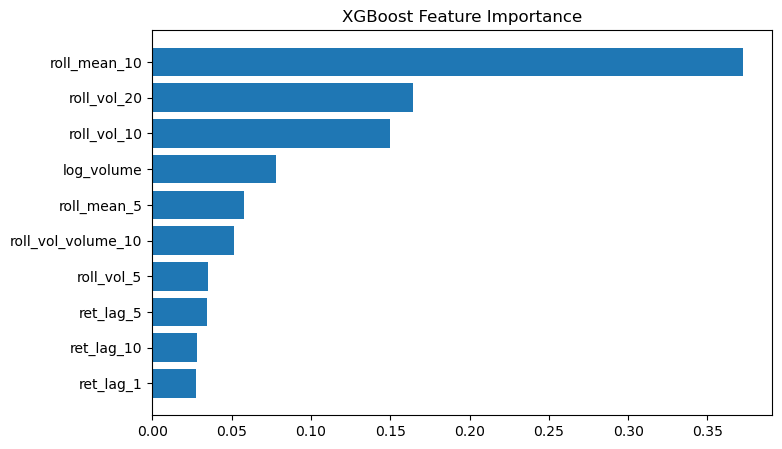

In [16]:
# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------
importance = xgb_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(feat_imp)

# -----------------------------
# PLOT (OPTIONAL BUT RECOMMENDED)
# -----------------------------
plt.figure(figsize=(8, 5))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()


In [17]:
SEQ_LEN = 20

def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X.iloc[i:i+seq_len].values)
        y_seq.append(y.iloc[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

# Create sequences
X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQ_LEN)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, SEQ_LEN)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, SEQ_LEN)

print("Train seq shape:", X_train_seq.shape)
print("Val seq shape  :", X_val_seq.shape)
print("Test seq shape :", X_test_seq.shape)


Train seq shape: (1875, 20, 10)
Val seq shape  : (386, 20, 10)
Test seq shape : (387, 20, 10)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train_seq.shape[2]

model = Sequential([
    LSTM(32, input_shape=(SEQ_LEN, n_features)),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50


C:\Users\Om Timbadiya\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0551 - val_loss: 5.6763e-04
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2720e-04 - val_loss: 5.6569e-05
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2329e-04 - val_loss: 5.6742e-05
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7553e-04 - val_loss: 9.7500e-05
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.2072e-05 - val_loss: 2.1341e-05
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7135e-05 - val_loss: 2.8495e-05
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0882e-05 - val_loss: 1.6352e-05
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.6947e-05 - val_loss: 1.6418e-05
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.4696e-05 - val_loss: 2.0102e-05
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.3587e-05 - val_loss: 2.4579e-05
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8327e-05 - val_loss: 1.5563e-05
E

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_lstm = model.predict(X_test_seq).flatten()

mae = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse = mean_squared_error(y_test_seq, y_pred_lstm, squared=False)

print("LSTM Performance on TEST set:")
print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
LSTM Performance on TEST set:
MAE : 0.003709
RMSE: 0.005262


C:\Users\Om Timbadiya\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [22]:
from sklearn.metrics import mean_absolute_error
import numpy as np

WINDOW = 1000   # training window size
HORIZON = 1     # step ahead (vol_5d already future-based)

y_true_all = []
y_pred_all = []
dates_all = []

for i in range(WINDOW, len(df) - 1):
    train_slice = df.iloc[i-WINDOW:i]
    test_slice = df.iloc[i:i+1]

    X_train_bt = train_slice[FEATURE_COLS]
    y_train_bt = train_slice["vol_5d"]

    X_test_bt = test_slice[FEATURE_COLS]
    y_test_bt = test_slice["vol_5d"]

    # retrain model (lightweight, realistic)
    model_bt = XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model_bt.fit(X_train_bt, y_train_bt, verbose=False)

    pred = model_bt.predict(X_test_bt)[0]

    y_true_all.append(y_test_bt.values[0])
    y_pred_all.append(pred)
    dates_all.append(test_slice["Date"].values[0])

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

print("Rolling Backtest MAE:", mean_absolute_error(y_true_all, y_pred_all))


Rolling Backtest MAE: 0.0031269520998432445


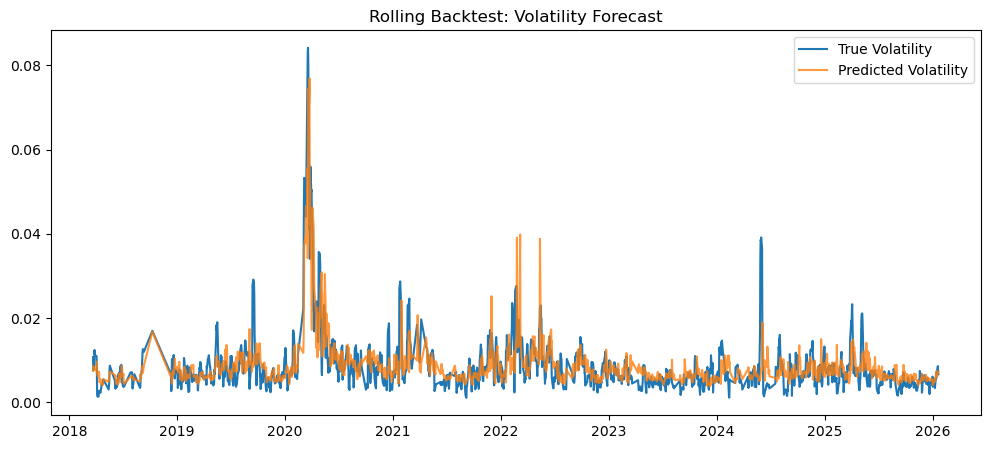

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(dates_all, y_true_all, label="True Volatility")
plt.plot(dates_all, y_pred_all, label="Predicted Volatility", alpha=0.8)
plt.legend()
plt.title("Rolling Backtest: Volatility Forecast")
plt.show()


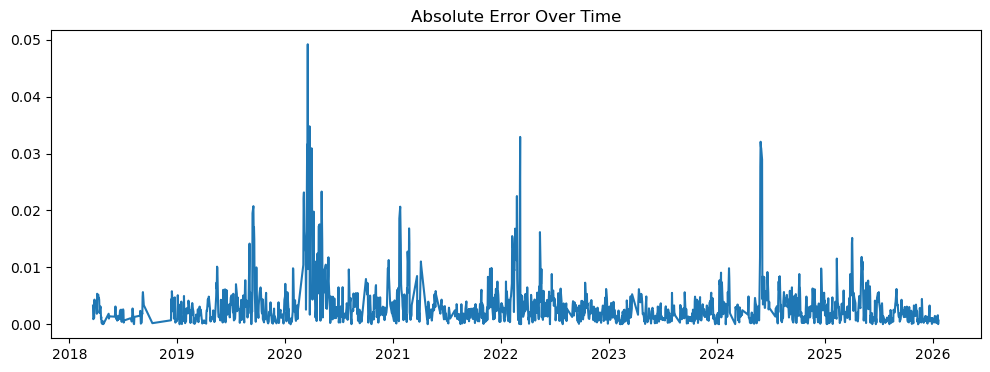

90th percentile error: 0.006129986689105593
Max error: 0.049199546003069944


In [24]:
abs_error = np.abs(y_true_all - y_pred_all)

plt.figure(figsize=(12,4))
plt.plot(dates_all, abs_error)
plt.title("Absolute Error Over Time")
plt.show()

print("90th percentile error:", np.percentile(abs_error, 90))
print("Max error:", abs_error.max())


In [ ]:
from xgboost import XGBRegressor

# Combine train + validation
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

final_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

final_model.fit(X_train_final, y_train_final)


import joblib
import json
from datetime import datetime
import os

# Create directories
os.makedirs("models/v1", exist_ok=True)

# Save model
joblib.dump(final_model, "models/v1/xgb_vol_5d.pkl")

# Save metadata
metadata = {
    "model_type": "XGBoost Regressor",
    "target": "vol_5d",
    "features": FEATURE_COLS,
    "trained_on": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "baseline_comparison": {
        "naive_mae": 0.003618,
        "ewma_mae": 0.003349,
        "xgb_test_mae": 0.003195
    }
}

with open("models/v1/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Model and metadata saved successfully.")


In [27]:
# Load back and test
loaded_model = joblib.load("models/v1/xgb_vol_5d.pkl")

test_pred = loaded_model.predict(X_test[:5])
print("Sample predictions:", test_pred)


Sample predictions: [0.00649977 0.00716691 0.00596914 0.00591069 0.00466981]


In [29]:
!pip install fastAPI

  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)


In [31]:
print(df.columns)


Index(['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'log_return', 'vol_5d', 'vol_10d', 'ret_lag_1', 'ret_lag_5',
       'ret_lag_10', 'roll_vol_5', 'roll_vol_10', 'roll_vol_20', 'roll_mean_5',
       'roll_mean_10', 'log_volume', 'roll_vol_volume_10', 'ewma_vol'],
      dtype='object')


In [32]:
FEATURE_COLS = [
    "ret_lag_1", "ret_lag_5", "ret_lag_10",
    "roll_vol_5", "roll_vol_10", "roll_vol_20",
    "roll_mean_5", "roll_mean_10",
    "log_volume", "roll_vol_volume_10"
]

TARGET_COL = "vol_10d"

X = df[FEATURE_COLS]
y = df[TARGET_COL]



In [33]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_naive = X_test["roll_vol_10"]

mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = mean_squared_error(y_test, y_pred_naive, squared=False)

print("Naive 10D Rolling Vol")
print("MAE :", mae_naive)
print("RMSE:", rmse_naive)


Naive 10D Rolling Vol
MAE : 0.00355014016662932
RMSE: 0.005780169210775311


C:\Users\Om Timbadiya\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [35]:
import numpy as np

def ewma_vol(series, alpha=0.94):
    ewma = []
    var = series.iloc[0] ** 2
    for r in series:
        var = alpha * var + (1 - alpha) * (r ** 2)
        ewma.append(np.sqrt(var))
    return np.array(ewma)

df["ewma_vol"] = ewma_vol(df["log_return"])

y_pred_ewma = df.iloc[val_end:]["ewma_vol"]

mae_ewma = mean_absolute_error(y_test, y_pred_ewma)
rmse_ewma = mean_squared_error(y_test, y_pred_ewma, squared=False)

print("EWMA Vol")
print("MAE :", mae_ewma)
print("RMSE:", rmse_ewma)


EWMA Vol
MAE : 0.002955722211653253
RMSE: 0.004831582947099323


C:\Users\Om Timbadiya\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [36]:
from xgboost import XGBRegressor

xgb_10d = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_10d.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [37]:
y_pred_xgb = xgb_10d.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb, squared=False)

print("XGBoost 10-Day Volatility")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)


XGBoost 10-Day Volatility
MAE : 0.002996082894082132
RMSE: 0.004584311776328206


C:\Users\Om Timbadiya\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [38]:
import joblib

joblib.dump(xgb_10d, "models/xgb_vol_10d.pkl")


['models/xgb_vol_10d.pkl']